In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [4]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.shape


(4000, 28)

In [6]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Rainfall_mm                      1.2
Soil_Moisture_pct                1.0
Yield_Tonnes_Ha                  0.8
Farm_ID                          0.0
Irrigation_Method                0.0
Water_Efficiency_t_per_1000m3    0.0
Water_Used_m3                    0.0
Profit_INR                       0.0
Revenue_INR                      0.0
Total_Cost_INR                   0.0
Market_Price_INR_Tonne           0.0
Production_Tonnes                0.0
Seed_Quality_Score               0.0
Pesticide_Litre_ha               0.0
Fertilizer_kg_ha                 0.0
Potassium_kg_ha                  0.0
State                            0.0
Phosphorus_kg_ha                 0.0
Nitrogen_kg_ha                   0.0
Soil_pH                          0.0
Sunlight_Hours_Day               0.0
Humidity_pct                     0.0
Avg_Temperature_C                0.0
Farm_Area_Hectares               0.0
Season                           0.0
Crop                             0.0
District                         0.0
D

In [14]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())
    for col in categorical_columns:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(4000, 28)

In [18]:
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [19]:
df['Crop'].value_counts()


Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

In [20]:
df['State'].value_counts()

State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

In [21]:
df['Irrigation_Method'].value_counts()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

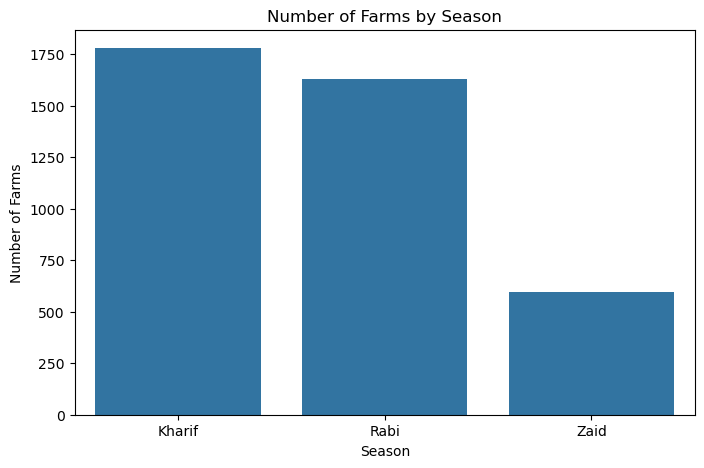

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Season')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

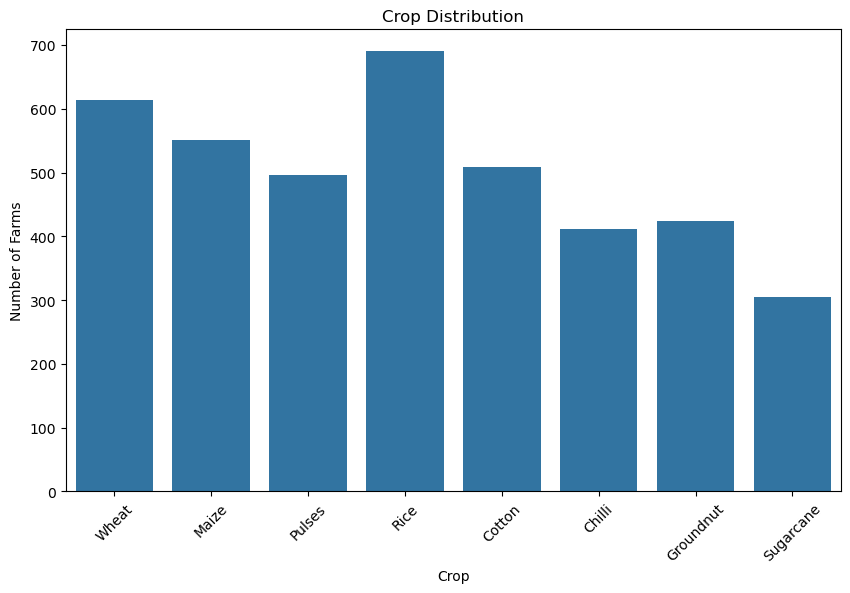

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x='Crop')

plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)

plt.show()

In [24]:
season_performance = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
})

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Total_Cost_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555,531804.408094,6102.201237,5.891834
Rabi,5.039435,41.486712,601526.048556,87689.470191,513836.578365,5846.987093,5.186122
Zaid,4.641313,38.886111,519171.904040,-24804.824916,543976.728956,6419.893939,4.413239


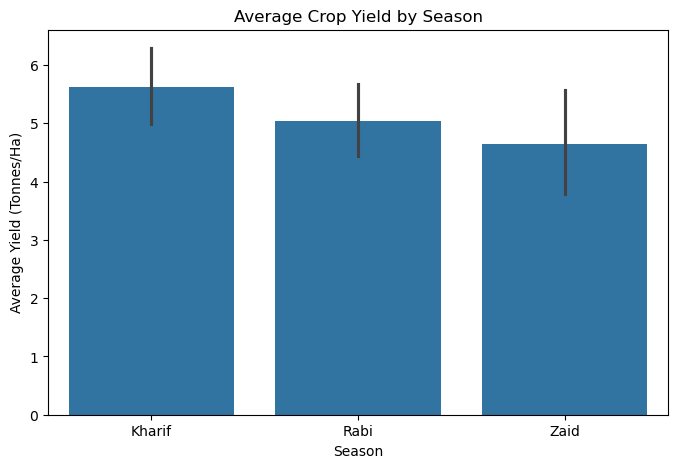

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

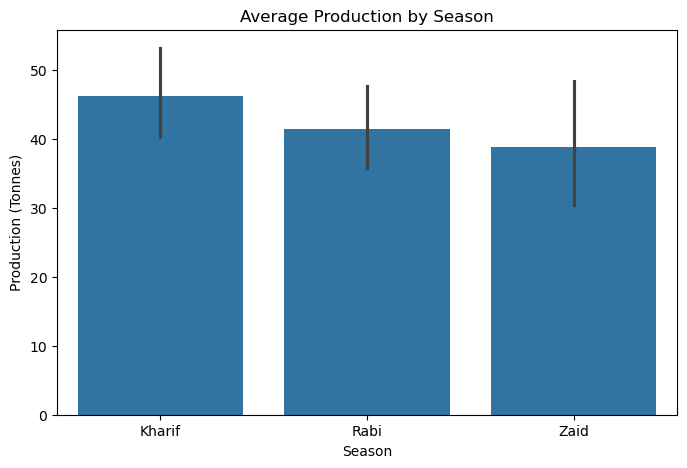

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Production_Tonnes'
)

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')

plt.show()

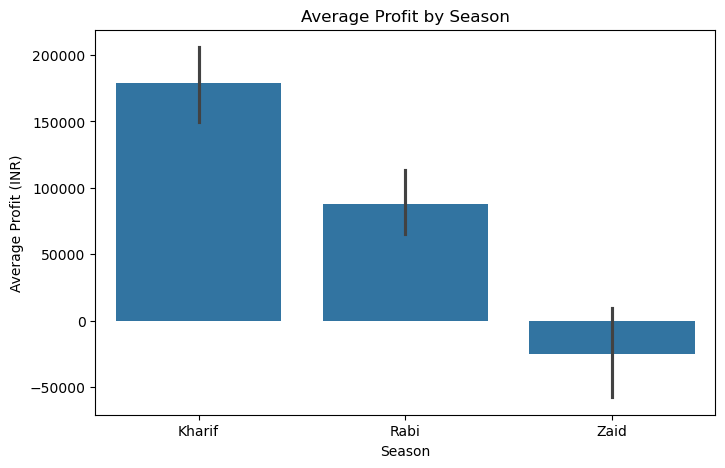

In [28]:
#Profit by Season

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

In [29]:
#Revenue vs Cost by Season

financial_summary = df.groupby('Season')[[
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]].mean()

financial_summary

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.408094,710719.055649,178914.647555
Rabi,513836.578365,601526.048556,87689.470191
Zaid,543976.728956,519171.904040,-24804.824916


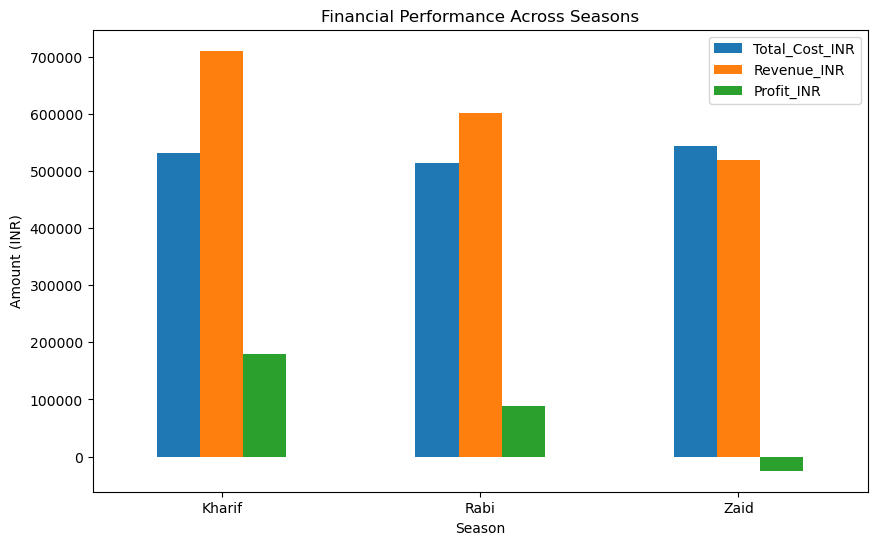

In [30]:
financial_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Financial Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)

plt.show()

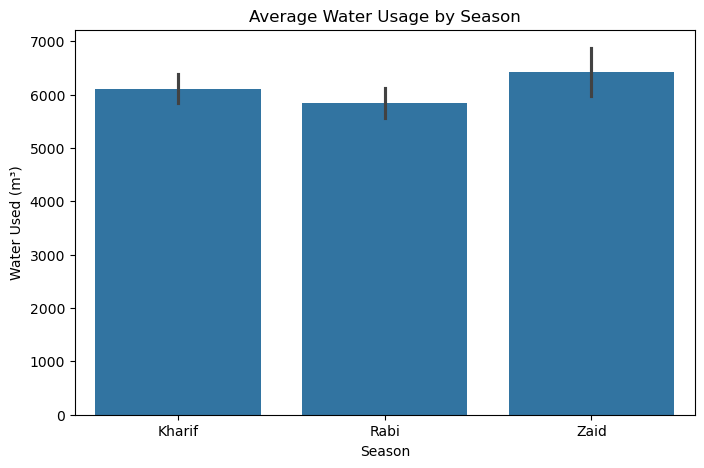

In [31]:
#Resource Usage by Season

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Used_m3'
)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.show()

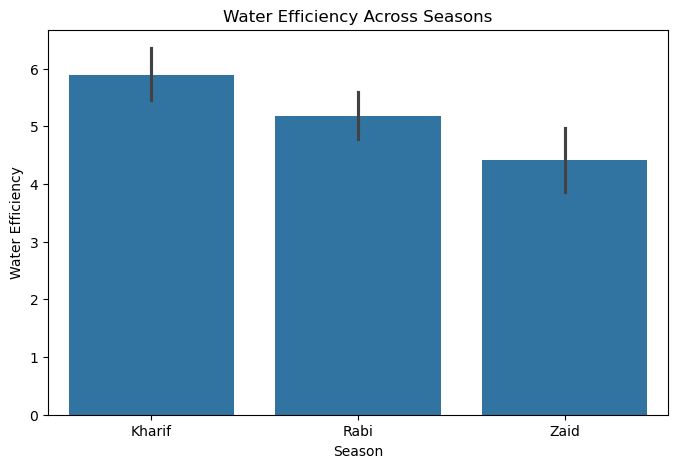

In [32]:
#Water efficiency

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3'
)

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency')

plt.show()

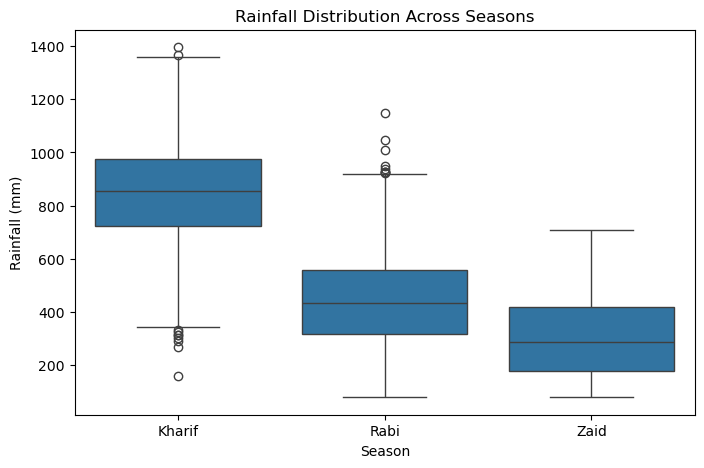

In [33]:
#Rainfall by season

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Rainfall_mm'
)

plt.title('Rainfall Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.show()

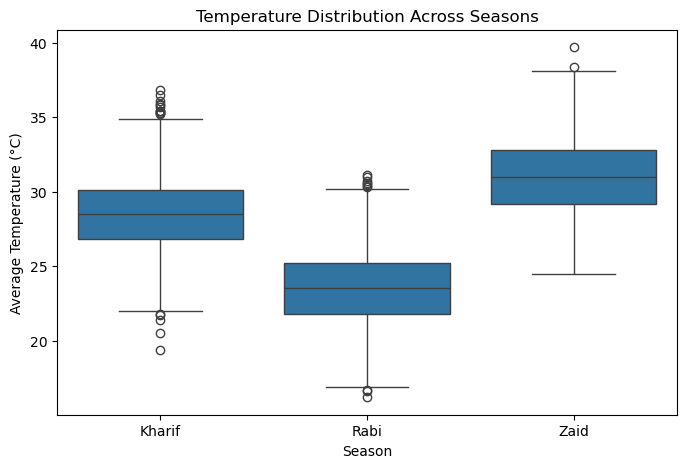

In [34]:
#Temperature by season

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title('Temperature Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')

plt.show()

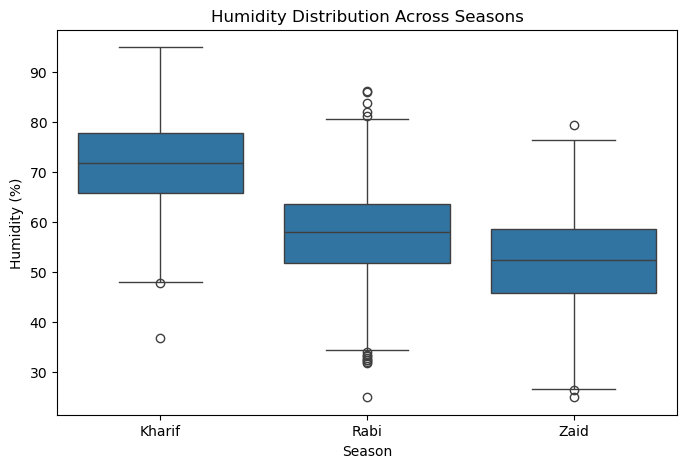

In [35]:
#Humidity

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Humidity_pct'
)

plt.title('Humidity Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Humidity (%)')

plt.show()

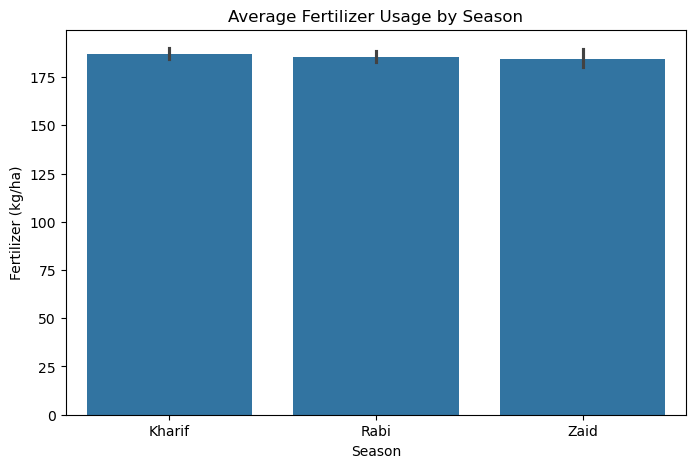

In [36]:
#Fertilizer usage

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Fertilizer_kg_ha'
)

plt.title('Average Fertilizer Usage by Season')
plt.xlabel('Season')
plt.ylabel('Fertilizer (kg/ha)')

plt.show()

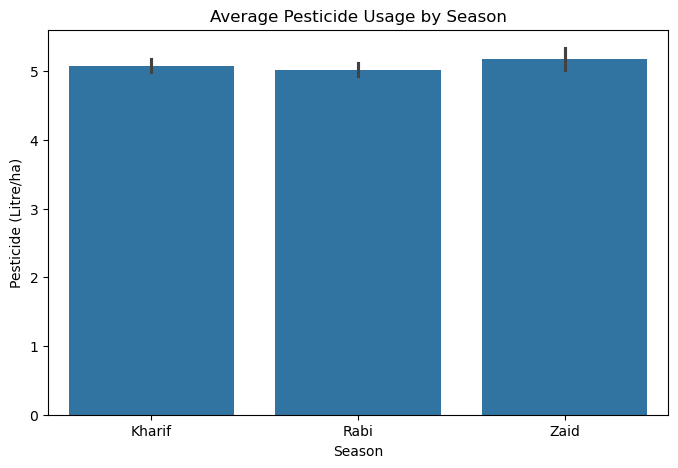

In [37]:
#Pesticide usage

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Pesticide_Litre_ha'
)

plt.title('Average Pesticide Usage by Season')
plt.xlabel('Season')
plt.ylabel('Pesticide (Litre/ha)')

plt.show()

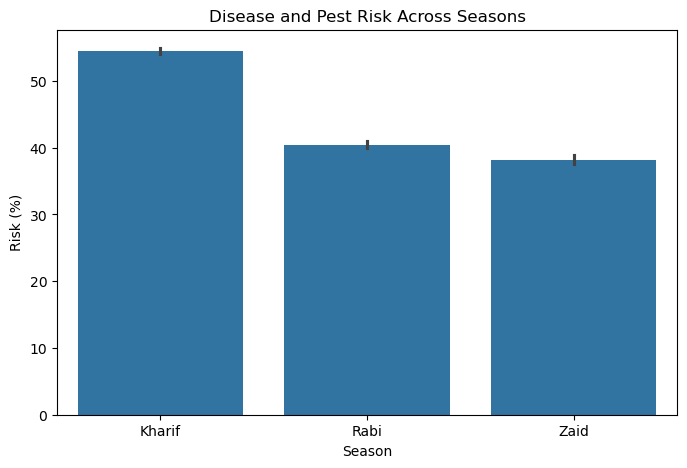

In [38]:
#Disease/Pest Risk

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title('Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Risk (%)')

plt.show()

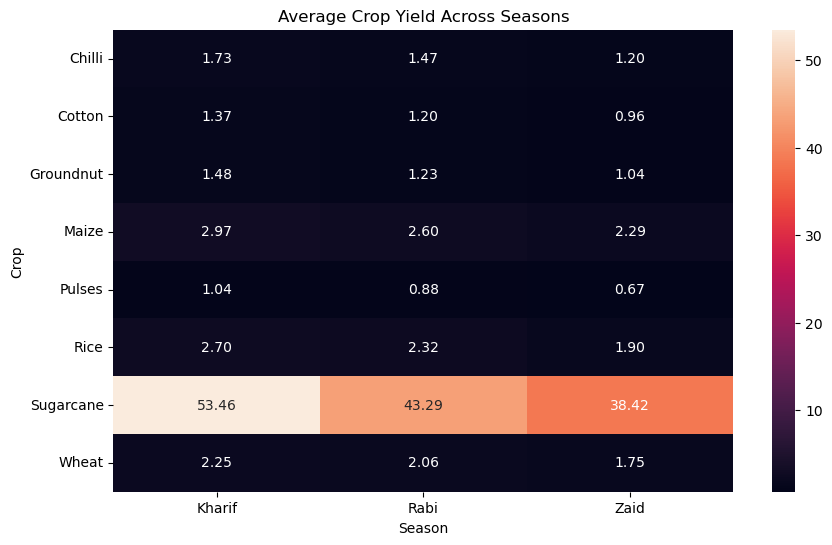

In [39]:
#Crop vs Season Analysis

crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield

plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Yield Across Seasons')

plt.show()

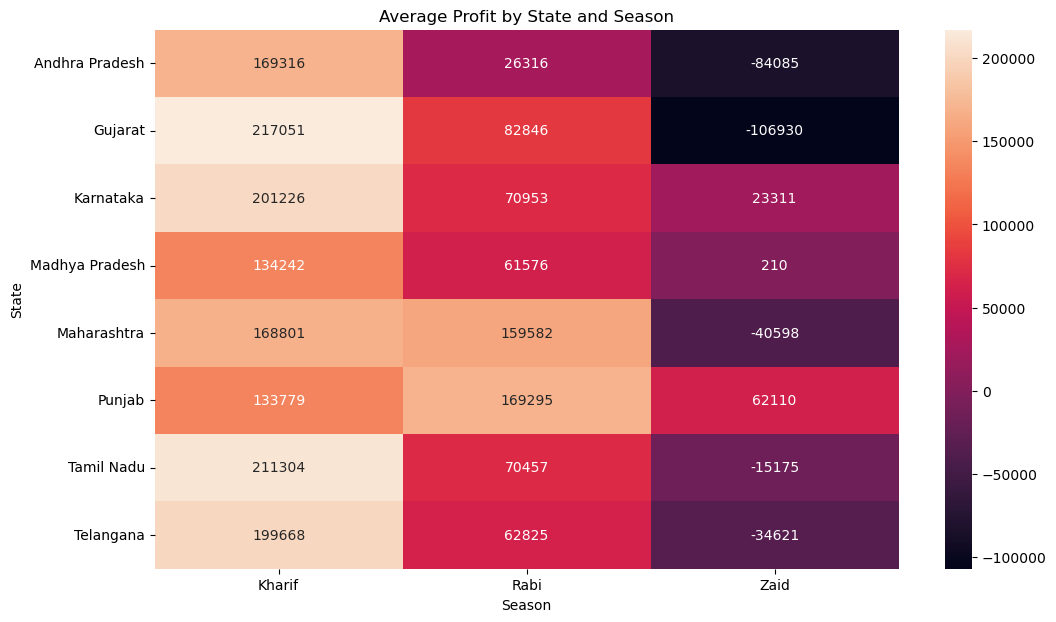

In [40]:
#State vs Season Analysis

state_season_profit = df.pivot_table(
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season_profit

plt.figure(figsize=(12,7))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt='.0f'
)

plt.title('Average Profit by State and Season')

plt.show()

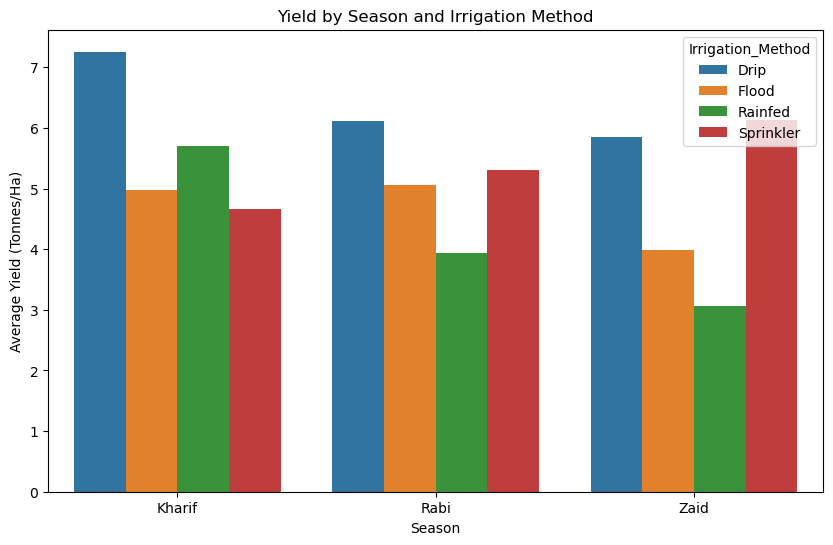

In [41]:
#Irrigation Method Analysis

irrigation_summary = df.groupby(
    ['Season', 'Irrigation_Method']
)['Yield_Tonnes_Ha'].mean().reset_index()

irrigation_summary

plt.figure(figsize=(10,6))

sns.barplot(
    data=irrigation_summary,
    x='Season',
    y='Yield_Tonnes_Ha',
    hue='Irrigation_Method'
)

plt.title('Yield by Season and Irrigation Method')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

In [42]:
correlation = df.select_dtypes(include=np.number).corr()

correlation

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,...,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,...,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,...,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,...,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,...,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,...,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,...,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,...,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,...,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,...,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


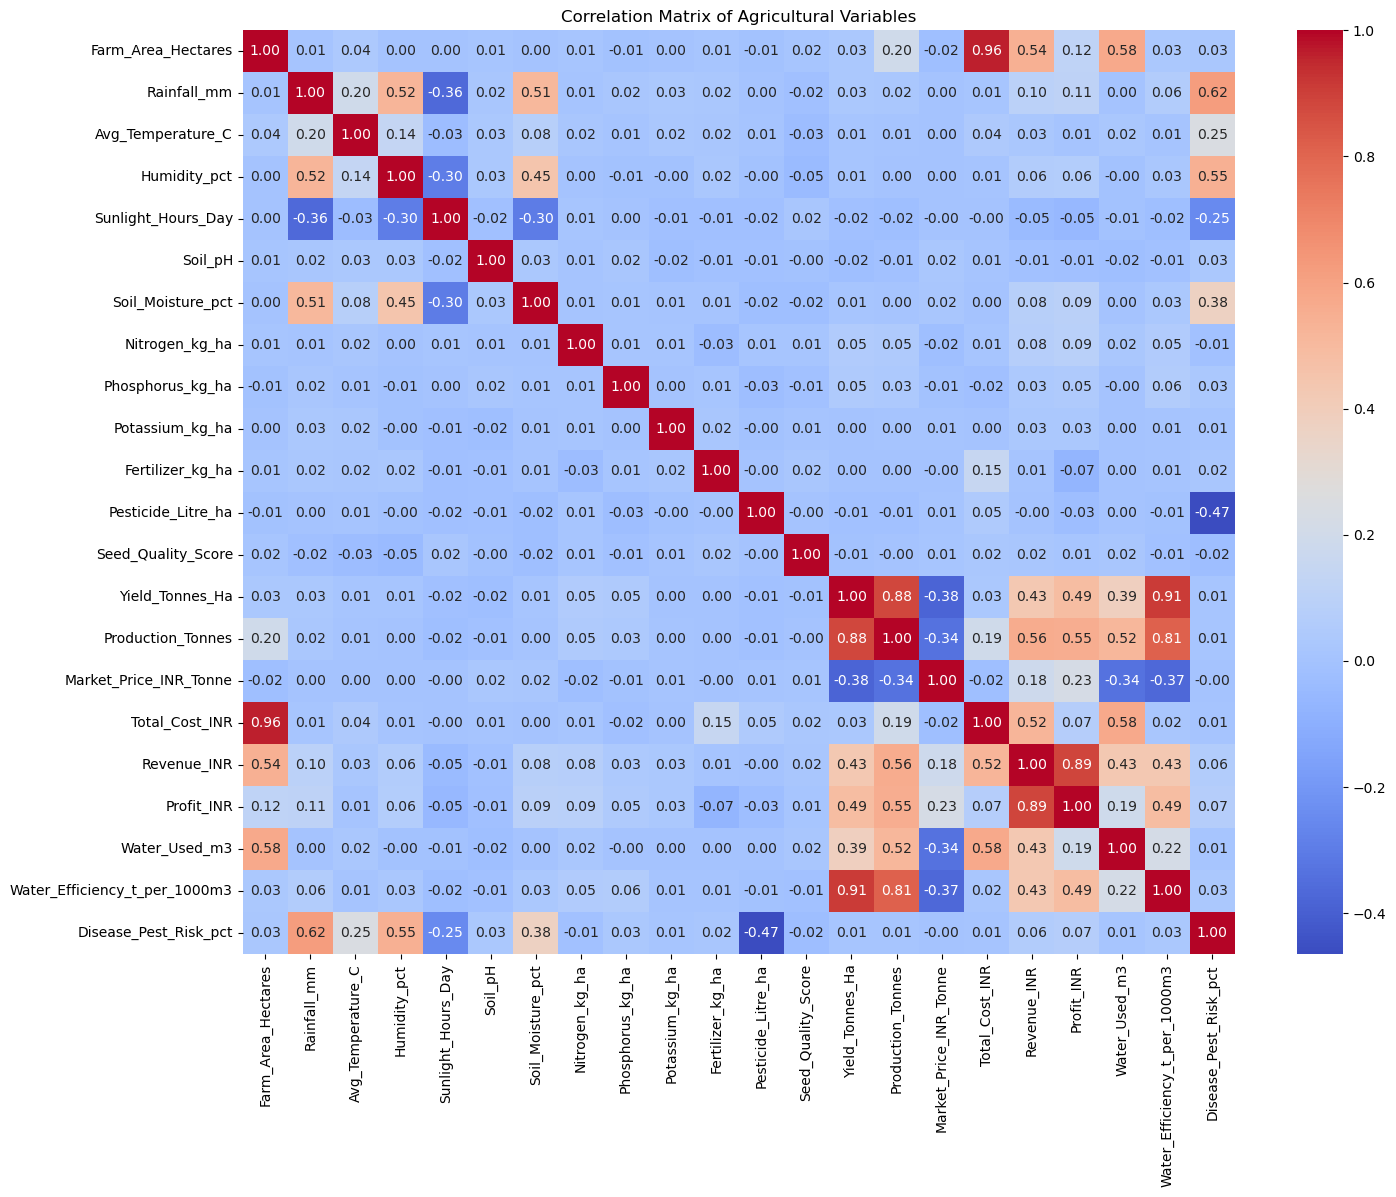

In [43]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.show()

In [44]:
#Identify important correlations

yield_correlation = correlation['Yield_Tonnes_Ha'].sort_values(ascending=False)
yield_correlation

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64

In [45]:
profit_correlation = correlation['Profit_INR'].sort_values(ascending=False)
profit_correlation

Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.107648
Soil_Moisture_pct                0.091281
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64

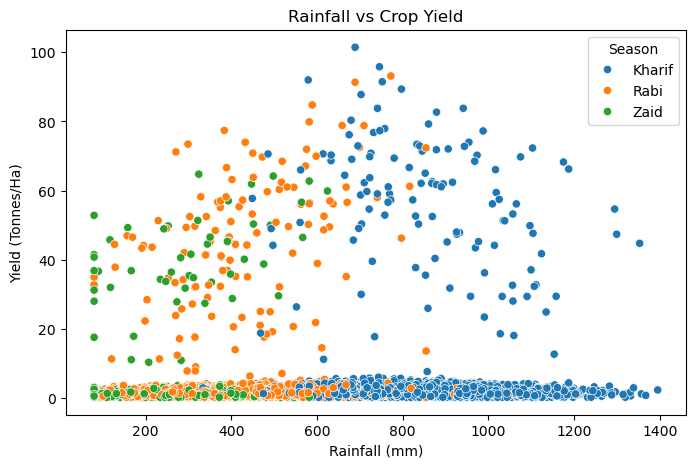

In [46]:
#Rainfall vs Yield

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

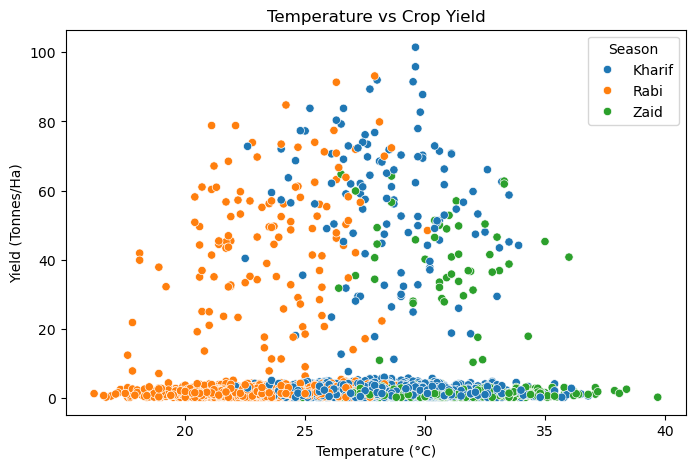

In [47]:
#Temperature vs Yield

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Temperature vs Crop Yield')
plt.xlabel('Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

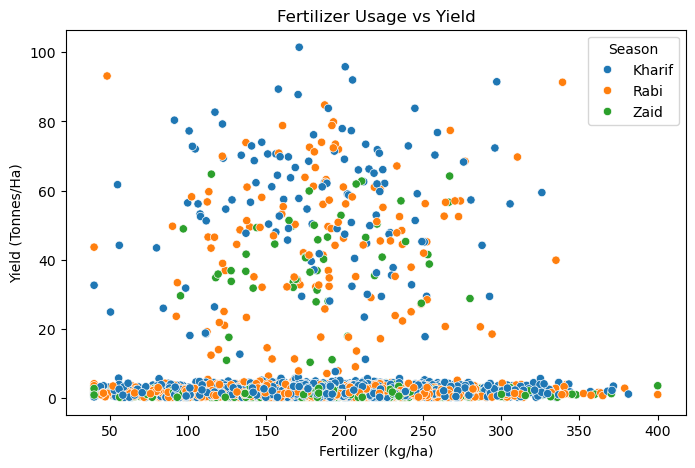

In [48]:
#Fertilizer vs Yield

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Fertilizer Usage vs Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

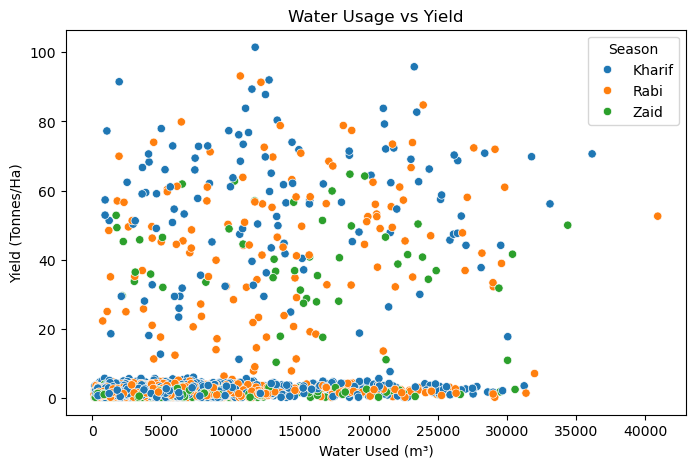

In [49]:
#Water Usage vs Yield

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Water Usage vs Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [50]:
#Statistical Analysis

kharif = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

anova_result = stats.f_oneway(
    kharif,
    rabi,
    zaid
)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [51]:
if anova_result.pvalue < 0.05:
    print("There is a statistically significant difference in yield among seasons.")
else:
    print("There is no statistically significant difference in yield among seasons.")

There is no statistically significant difference in yield among seasons.


In [52]:
average_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

best_yield_season = average_yield.idxmax()

print("Best season based on average yield:", best_yield_season)

Best season based on average yield: Kharif


In [53]:
average_profit = df.groupby('Season')['Profit_INR'].mean()

best_profit_season = average_profit.idxmax()

print("Best season based on average profit:", best_profit_season)

Best season based on average profit: Kharif


In [54]:
#Find unusual patterns / outliers

Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Yield_Tonnes_Ha'] < lower_bound) |
    (df['Yield_Tonnes_Ha'] > upper_bound)
]

print("Number of yield outliers:", len(outliers))

Number of yield outliers: 302


In [55]:
#Final summary table

In [56]:
final_summary = df.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
)

final_summary

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Pest_Risk
Season,,,,,,,,
Kharif,5.628612,46.311192,710719.055649,531804.408094,178914.647555,6102.201237,5.891834,54.467903
Rabi,5.039435,41.486712,601526.048556,513836.578365,87689.470191,5846.987093,5.186122,40.482114
Zaid,4.641313,38.886111,519171.904040,543976.728956,-24804.824916,6419.893939,4.413239,38.216667


In [57]:
final_summary = final_summary.round(2)

final_summary

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Pest_Risk
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22
